In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
pd.set_option('display.max_columns', None)

In [58]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [59]:
df.shape

(3553, 18)

In [60]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,the close north,sector 50,2.35,11768.0,3,3,3+,8.0,Moderately Old,1950.0,0,0,0,0,0,2,165
1,flat,ats tourmaline,sector 109,2.30,8897.0,3,4,3+,10.0,New Property,2339.0,0,1,0,0,1,0,74
2,house,unitech espace,sector 50,7.50,34722.0,3,3,2,2.0,Moderately Old,2160.0,0,1,0,0,0,2,66
3,flat,rof ananda,sector 95,0.46,6319.0,2,2,2,11.0,New Property,809.0,1,0,0,0,0,0,82
4,house,prem kunj,sohna road road,0.50,7407.0,2,4,3,3.0,Relatively New,725.0,0,0,0,1,0,0,22


In [61]:
train_df = df.drop(columns=['society','price_per_sqft'])

In [62]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sector 50,2.35,3,3,3+,8.0,Moderately Old,1950.0,0,0,0,0,0,2,165
1,flat,sector 109,2.30,3,4,3+,10.0,New Property,2339.0,0,1,0,0,1,0,74
2,house,sector 50,7.50,3,3,2,2.0,Moderately Old,2160.0,0,1,0,0,0,2,66
3,flat,sector 95,0.46,2,2,2,11.0,New Property,809.0,1,0,0,0,0,0,82
4,house,sohna road road,0.50,2,4,3,3.0,Relatively New,725.0,0,0,0,1,0,0,22


### luxury score

<Axes: >

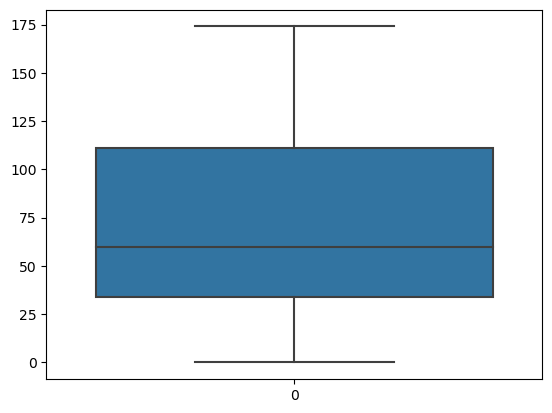

In [63]:
sns.boxplot(df['luxury_score'])

In [64]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None  # or "Undefined" or any other label for scores outside the defined bins

In [65]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [66]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,flat,sector 50,2.35,3,3,3+,8.0,Moderately Old,1950.0,0,0,0,0,0,2,165,High
1,flat,sector 109,2.30,3,4,3+,10.0,New Property,2339.0,0,1,0,0,1,0,74,Medium
2,house,sector 50,7.50,3,3,2,2.0,Moderately Old,2160.0,0,1,0,0,0,2,66,Medium
3,flat,sector 95,0.46,2,2,2,11.0,New Property,809.0,1,0,0,0,0,0,82,Medium
4,house,sohna road road,0.50,2,4,3,3.0,Relatively New,725.0,0,0,0,1,0,0,22,Low


### floorNum

<Axes: >

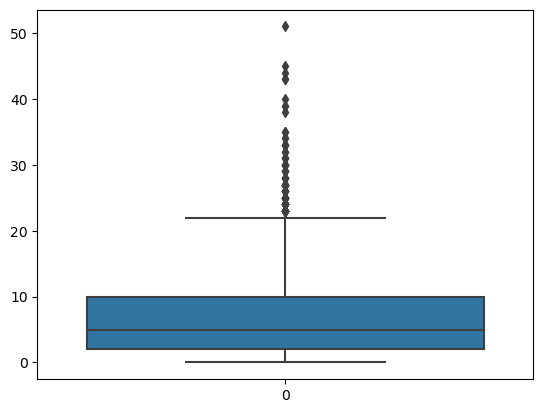

In [67]:
sns.boxplot(df['floorNum'])

In [68]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None  # or "Undefined" or any other label for floors outside the defined bins

In [69]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [70]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,flat,sector 50,2.35,3,3,3+,8.0,Moderately Old,1950.0,0,0,0,0,0,2,165,High,Mid Floor
1,flat,sector 109,2.30,3,4,3+,10.0,New Property,2339.0,0,1,0,0,1,0,74,Medium,Mid Floor
2,house,sector 50,7.50,3,3,2,2.0,Moderately Old,2160.0,0,1,0,0,0,2,66,Medium,Low Floor
3,flat,sector 95,0.46,2,2,2,11.0,New Property,809.0,1,0,0,0,0,0,82,Medium,High Floor
4,house,sohna road road,0.50,2,4,3,3.0,Relatively New,725.0,0,0,0,1,0,0,22,Low,Mid Floor


In [71]:
train_df.drop(columns=['floorNum','luxury_score'],inplace=True)

In [72]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,flat,sector 50,2.35,3,3,3+,Moderately Old,1950.0,0,0,0,0,0,2,High,Mid Floor
1,flat,sector 109,2.30,3,4,3+,New Property,2339.0,0,1,0,0,1,0,Medium,Mid Floor
2,house,sector 50,7.50,3,3,2,Moderately Old,2160.0,0,1,0,0,0,2,Medium,Low Floor
3,flat,sector 95,0.46,2,2,2,New Property,809.0,1,0,0,0,0,0,Medium,High Floor
4,house,sohna road road,0.50,2,4,3,Relatively New,725.0,0,0,0,1,0,0,Low,Mid Floor


# Label Encoding

In [73]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the original data for label encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

# Splitting the dataset into training and testing sets
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'new',
       'new sector 2', 'sector 1', 'sector 102', 'sector 103',
       'sector 104', 'sector 105', 'sector 106', 'sector 107',
       'sector 108', 'sector 109', 'sector 10a', 'sector 11',
       'sector 110', 'sector 111', 'sector 112', 'sector 113',
       'sector 12', 'sector 13', 'sector 14', 'sector 15', 'sector 17',
       'sector 17a', 'sector 17b', 'sector 2', 'sector 21', 'sector 22',
       'sector 23', 'sector 24', 'sector 25', 'sector 26', 'sector 27',
       'sector 28', 'sector 3', 'sector 3 phase 2',
       'sector 3 phase 3 extension', 'sector 30', 'sector 31',
       'sector 33', 'sector 36', 'sector 36a', 'sector 37', 'sector 37c',
       'sector 37d', 'sector 38', 'sector 39', 'sector 4', 'sector 40',
       'sector 41', 'sector 43', 'sector 45', 'sector 46', 'sector 47',
       'sector 48', 'sector 49', 'sector 5', 'sector 50', 'sector 51',
       'sector 52', 'sect

In [74]:
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,59.0,3,3,4.0,0.0,1950.0,0,0,0,0,0,2,0.0,2.0
1,0.0,13.0,3,4,4.0,1.0,2339.0,0,1,0,0,1,0,2.0,2.0
2,1.0,59.0,3,3,2.0,0.0,2160.0,0,1,0,0,0,2,2.0,1.0
3,0.0,109.0,2,2,2.0,1.0,809.0,1,0,0,0,0,0,2.0,0.0
4,1.0,114.0,2,4,3.0,3.0,725.0,0,0,0,1,0,0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3548,0.0,97.0,2,2,2.0,3.0,990.0,0,0,0,0,0,2,0.0,1.0
3549,0.0,41.0,3,4,2.0,0.0,1398.0,0,1,0,0,0,0,1.0,2.0
3550,0.0,105.0,2,2,3.0,3.0,1122.0,1,0,0,0,0,0,2.0,2.0
3551,0.0,57.0,4,4,4.0,0.0,2157.0,0,1,0,0,0,0,2.0,2.0


In [75]:
y_label

0       2.35
1       2.30
2       7.50
3       0.46
4       0.50
        ... 
3548    0.60
3549    1.35
3550    0.66
3551    2.90
3552    1.50
Name: price, Length: 3553, dtype: float64

# Feature Selection

### Technique 1 - Correlation Analysis

<Axes: >

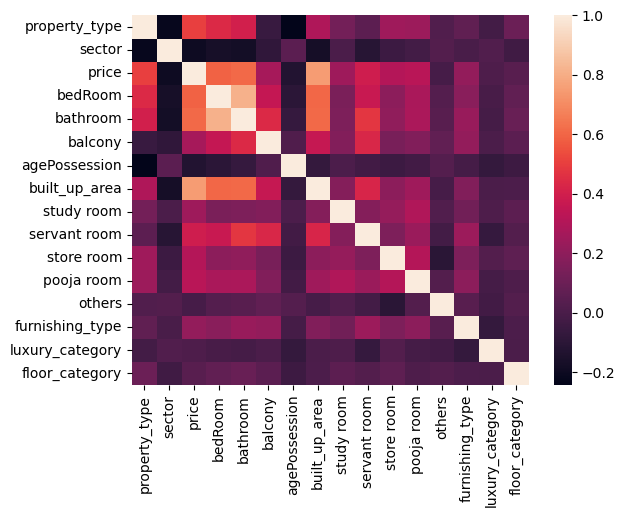

In [76]:
 sns.heatmap(data_label_encoded.corr())

In [77]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,sector,-0.199412
1,price,1.000000
2,bedRoom,0.591282
3,bathroom,0.609772
4,balcony,0.269788
5,agePossession,-0.130294
6,built_up_area,0.748565
7,study room,0.242923
8,servant room,0.391899
9,store room,0.305657


### Technique 2 - Random Forest Feature Importance

In [78]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
6,built_up_area,0.647477
1,sector,0.107811
0,property_type,0.106449
3,bathroom,0.024875
2,bedRoom,0.022442
8,servant room,0.020035
5,agePossession,0.014154
4,balcony,0.012672
9,store room,0.008027
13,luxury_category,0.007267


### Technique 3 - Gradient Boosting Feature importances

In [79]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
6,built_up_area,0.678555
1,sector,0.104876
0,property_type,0.097953
2,bedRoom,0.036551
3,bathroom,0.036095
8,servant room,0.023423
9,store room,0.009490
5,agePossession,0.005201
7,study room,0.003412
12,furnishing_type,0.001794


### Technique 4 - Permutation Importance

In [80]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
6,built_up_area,0.760432
0,property_type,0.197205
1,sector,0.123467
3,bathroom,0.016768
8,servant room,0.013356
2,bedRoom,0.008928
7,study room,0.003123
9,store room,0.001178
13,luxury_category,0.001160
14,floor_category,-0.000394


### Technique 5 - LASSO

In [81]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5


,feature,lasso_coeff
6,built_up_area,1.511100
0,property_type,0.707796
3,bathroom,0.281146
9,store room,0.199200
7,study room,0.175996
8,servant room,0.165994
12,furnishing_type,0.138452
10,pooja room,0.075255
13,luxury_category,0.048878
2,bedRoom,0.018288


### Technique 6 - RFE

In [82]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6


,feature,rfe_score
6,built_up_area,0.654697
1,sector,0.104100
0,property_type,0.104097
3,bathroom,0.023002
2,bedRoom,0.022788
8,servant room,0.020507
5,agePossession,0.014254
4,balcony,0.012112
7,study room,0.008116
9,store room,0.007612


### Technique 7 - Linear Regression Weights

In [83]:
# Train a linear regression model on the label-encoded and standardized training data
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7


,feature,reg_coeffs
6,built_up_area,1.513447
0,property_type,0.705211
3,bathroom,0.288730
9,store room,0.203656
7,study room,0.184542
8,servant room,0.174900
12,furnishing_type,0.147501
10,pooja room,0.078434
13,luxury_category,0.059457
2,bedRoom,0.020919


### Technique 8 - SHAP

In [101]:
# !pip install shap

In [85]:
import shap


In [86]:
import shap

# Compute SHAP values using the trained Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_label)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)

shap_values


array([[-4.31067550e-01,  3.64690407e-01, -1.42061854e-02, ...,
         1.80662631e-02,  7.32085672e-02, -6.10173279e-02],
       [-4.62124405e-01, -2.48642512e-01, -9.89808467e-03, ...,
        -4.60468525e-02,  4.00339520e-03, -5.70688776e-02],
       [ 2.06701898e+00,  6.24681157e-01,  3.62780607e-04, ...,
         5.55885370e-02,  4.09343799e-02,  4.99982039e-03],
       ...,
       [-2.06994945e-01, -5.10409914e-01, -4.31813131e-02, ...,
        -6.40570037e-03, -2.82779377e-03, -4.91378298e-03],
       [-5.74418496e-01,  3.78750537e-01,  3.28333367e-02, ...,
        -3.51145523e-03, -7.29380691e-03,  8.41500054e-03],
       [-4.02019118e-01, -6.67706313e-01,  1.88779498e-02, ...,
        -1.31550046e-02, -4.74671322e-03,  1.24314168e-03]])

In [87]:
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,feature,SHAP_score
6,built_up_area,1.249494
0,property_type,0.489085
1,sector,0.384285
3,bathroom,0.115285
8,servant room,0.089870
2,bedRoom,0.047440
4,balcony,0.040741
14,floor_category,0.025294
5,agePossession,0.024907
12,furnishing_type,0.022227


In [88]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature').set_index('feature')

In [89]:
final_fi_df


,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
feature,,,,,,,,
sector,-0.199412,0.107811,0.104876,0.123467,-0.049054,0.104100,-0.058041,0.384285
bedRoom,0.591282,0.022442,0.036551,0.008928,0.018288,0.022788,0.020919,0.047440
bathroom,0.609772,0.024875,0.036095,0.016768,0.281146,0.023002,0.288730,0.115285
balcony,0.269788,0.012672,0.001499,-0.002106,-0.045274,0.012112,-0.068375,0.040741
agePossession,-0.130294,0.014154,0.005201,-0.001857,-0.023501,0.014254,-0.031170,0.024907
built_up_area,0.748565,0.647477,0.678555,0.760432,1.511100,0.654697,1.513447,1.249494
study room,0.242923,0.006254,0.003412,0.003123,0.175996,0.008116,0.184542,0.018045
servant room,0.391899,0.020035,0.023423,0.013356,0.165994,0.020507,0.174900,0.089870
store room,0.305657,0.008027,0.009490,0.001178,0.199200,0.007612,0.203656,0.017267


In [90]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [91]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score','SHAP_score']].mean(axis=1).sort_values(ascending=False)

feature
built_up_area      0.728593
sector             0.134768
bathroom           0.033516
servant room       0.025863
bedRoom            0.024752
agePossession      0.009505
balcony            0.009350
store room         0.007527
study room         0.006395
furnishing_type    0.005412
floor_category     0.005344
luxury_category    0.004931
pooja room         0.002136
others             0.001908
dtype: float64

In [92]:
# to drop pooja room, study room, others
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,59.0,3,3,4.0,0.0,1950.0,0,0,0,0,0,2,0.0,2.0
1,0.0,13.0,3,4,4.0,1.0,2339.0,0,1,0,0,1,0,2.0,2.0
2,1.0,59.0,3,3,2.0,0.0,2160.0,0,1,0,0,0,2,2.0,1.0
3,0.0,109.0,2,2,2.0,1.0,809.0,1,0,0,0,0,0,2.0,0.0
4,1.0,114.0,2,4,3.0,3.0,725.0,0,0,0,1,0,0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3548,0.0,97.0,2,2,2.0,3.0,990.0,0,0,0,0,0,2,0.0,1.0
3549,0.0,41.0,3,4,2.0,0.0,1398.0,0,1,0,0,0,0,1.0,2.0
3550,0.0,105.0,2,2,3.0,3.0,1122.0,1,0,0,0,0,0,2.0,2.0
3551,0.0,57.0,4,4,4.0,0.0,2157.0,0,1,0,0,0,0,2.0,2.0


In [93]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [94]:
scores.mean()

0.8052806585829995

In [95]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['pooja room', 'study room', 'others']), y_label, cv=5, scoring='r2')

In [96]:
scores.mean()

0.8034351893494305

In [97]:
export_df = X_label.drop(columns=['pooja room', 'study room', 'others'])
export_df['price'] = y_label

In [98]:
export_df.to_csv('gurgaon_properties_post_feature_selection.csv', index=False)

In [99]:
export_df

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,price
0,0.0,59.0,3,3,4.0,0.0,1950.0,0,0,2,0.0,2.0,2.35
1,0.0,13.0,3,4,4.0,1.0,2339.0,1,0,0,2.0,2.0,2.30
2,1.0,59.0,3,3,2.0,0.0,2160.0,1,0,2,2.0,1.0,7.50
3,0.0,109.0,2,2,2.0,1.0,809.0,0,0,0,2.0,0.0,0.46
4,1.0,114.0,2,4,3.0,3.0,725.0,0,0,0,1.0,2.0,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3548,0.0,97.0,2,2,2.0,3.0,990.0,0,0,2,0.0,1.0,0.60
3549,0.0,41.0,3,4,2.0,0.0,1398.0,1,0,0,1.0,2.0,1.35
3550,0.0,105.0,2,2,3.0,3.0,1122.0,0,0,0,2.0,2.0,0.66
3551,0.0,57.0,4,4,4.0,0.0,2157.0,1,0,0,2.0,2.0,2.90
